# Análisis Exploratorio de Datos (EDA): Relaciones Numéricas y Correlaciones
En este notebook analizaremos las relaciones bivariadas entre variables numéricas del dataset inmobiliario. 

**Objetivos:**
1. Calcular y comparar matrices de correlación de **Pearson** (lineal) y **Spearman** (monótona).
2. Visualizar patrones mediante Heatmaps y Scatter plots.
3. Aplicar algoritmos adicionales como **Información Mutua** (para dependencias no lineales) y **PCA** para entender la varianza de los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuración de estilo y advertencias
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Cargar el dataset
df = pd.read_csv(r"C:\Users\Ing. Antonio Rial\OneDrive - Universidad Austral\MCD_Laboratorio.de.Implementación.2\Competencia.House.Pricing\data\tabular\train_processed.csv", low_memory=False)

# Mostrar información inicial
print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

# Seleccionar únicamente columnas numéricas para el análisis de correlación
df_numeric = df.select_dtypes(include=[np.number])

# Eliminar columnas con más del 50% de valores nulos y rellenar el resto con la mediana
df_numeric = df_numeric.dropna(axis=1, thresh=int(0.5 * len(df_numeric)))
df_numeric = df_numeric.fillna(df_numeric.median())

print(f"\nColumnas numéricas seleccionadas para el análisis: {len(df_numeric.columns)}")
display(df_numeric.describe())

Dimensiones del dataset: (11840, 46)


,zpid,lastSoldPrice_hpi_adjusted,log_price,description,bedrooms,bathrooms,livingArea,yearBuilt,latitude,longitude,...,log_living_area,log_lot_area,zip_3digit,desc_length,desc_word_count,desc_is_boilerplate,desc_mentions_renovated,desc_mentions_pool,desc_mentions_view,desc_mentions_new
0,1011541,255691.210988,12.451730,This 665 square foot condo home has 1 bedrooms...,1.0,1.0,665.0,2006.0,26.616192,-80.054060,...,6.501290,0.693147,334,136,26,1,0,0,0,0
1,1005445,687261.362622,13.440471,This 1030 square foot condo home has 2 bedroom...,2.0,2.0,1030.0,1987.0,25.847658,-80.145710,...,6.938284,NaN,331,148,28,1,0,0,0,0
2,1002822,264917.298188,12.487177,This 980 square foot condo home has 2 bedrooms...,2.0,2.0,980.0,1974.0,26.307700,-80.095030,...,6.888572,NaN,334,140,27,1,0,0,0,0
3,1006212,861474.563930,13.666402,This 1237 square foot condo home has 2 bedroom...,2.0,2.0,1237.0,1970.0,25.987293,-80.118614,...,7.121252,7.121252,330,137,26,1,0,0,0,0
4,1007959,314224.747125,12.657867,This 978 square foot single family home has 3 ...,3.0,2.0,978.0,1961.0,26.580450,-80.104880,...,6.886532,8.836810,334,137,25,1,0,0,0,0



Columnas numéricas seleccionadas para el análisis: 44


,zpid,lastSoldPrice_hpi_adjusted,log_price,bedrooms,bathrooms,livingArea,yearBuilt,latitude,longitude,lotAreaValue,...,log_living_area,log_lot_area,zip_3digit,desc_length,desc_word_count,desc_is_boilerplate,desc_mentions_renovated,desc_mentions_pool,desc_mentions_view,desc_mentions_new
count,1.184000e+04,1.184000e+04,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,...,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000,11840.000000
mean,1.008799e+06,5.590194e+05,13.032547,2.428632,1.973758,1415.804476,1975.372213,26.037184,-80.179608,5050.357924,...,7.155438,7.604434,332.086655,302.487838,50.211655,0.517314,0.153209,0.188429,0.034797,0.047382
std,5.070509e+03,3.509714e+05,0.663308,1.030152,0.744921,664.628137,21.194773,0.388292,0.135757,2593.194057,...,0.507444,2.661534,1.500207,326.000953,51.236522,0.499721,0.360204,0.391071,0.183274,0.212463
min,1.000001e+06,5.127585e+04,10.844995,0.000000,0.000000,0.000000,1900.000000,25.506687,-85.636240,0.000000,...,0.000000,0.000000,321.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.004382e+06,3.039663e+05,12.624675,2.000000,1.500000,976.000000,1961.000000,25.733360,-80.242652,5009.000000,...,6.884487,8.519191,331.000000,135.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.008754e+06,4.722890e+05,13.065349,2.000000,2.000000,1311.000000,1973.000000,25.902540,-80.162410,5501.000000,...,7.179308,8.612867,331.000000,142.000000,27.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.013184e+06,7.292780e+05,13.499812,3.000000,2.000000,1720.000000,1988.000000,26.379992,-80.082820,6003.000000,...,7.450661,8.700181,334.000000,402.000000,63.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.017606e+06,1.986843e+06,14.502058,11.000000,10.000000,25163.000000,2027.000000,30.562725,-80.034134,18730.800367,...,10.133170,9.837978,349.000000,7540.000000,1325.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1. Análisis de Correlación: Pearson vs. Spearman

*   **Correlación de Pearson ($r$):** Mide la fuerza de una relación **lineal** entre dos variables continuas. Es muy sensible a *outliers* (valores atípicos), algo muy común en datos de precios inmobiliarios.
*   **Correlación de Spearman ($\rho$):** Evalúa relaciones **monótonas** (lineales o no lineales). Se basa en el rango de los valores, por lo que es robusta ante outliers y no requiere que la relación sea estrictamente una línea recta.

Variable objetivo seleccionada: lastSoldPrice_hpi_adjusted


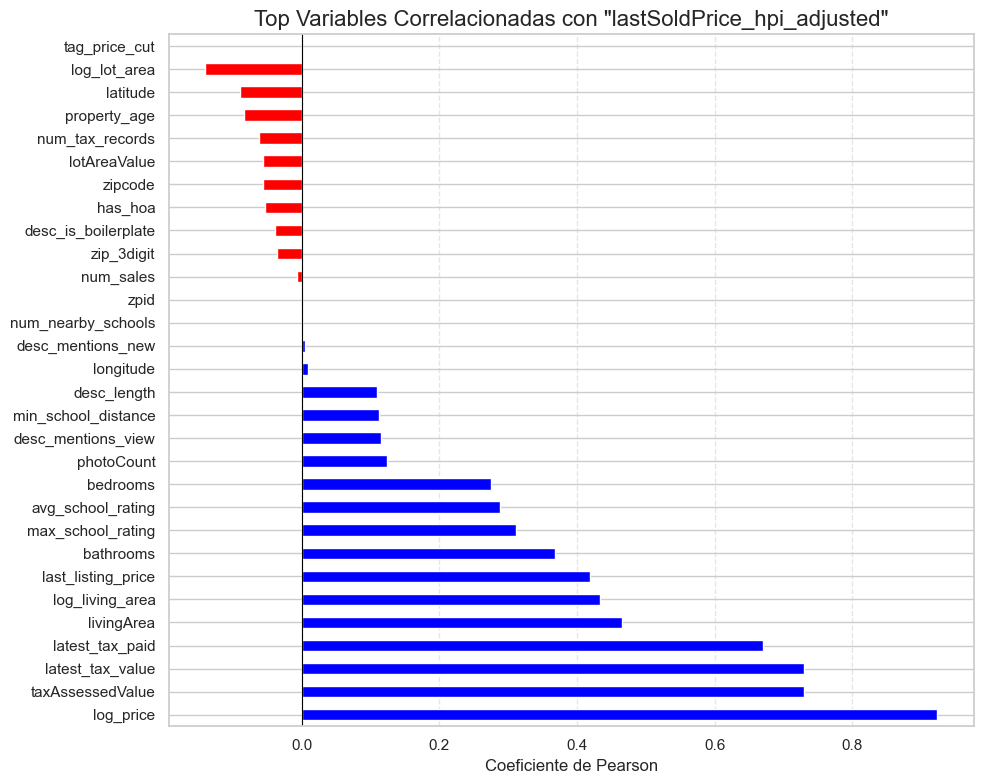

In [10]:
# Supongamos que la variable objetivo es la que contiene 'PRICE' o 'VAL'
target_candidates = [col for col in df_numeric.columns if 'PRICE' in col.upper() or 'VAL' in col.upper()]
target_col = target_candidates[0] if target_candidates else df_numeric.columns[-1]

print(f"Variable objetivo seleccionada: {target_col}")

# Calcular correlación de todas las variables CON respecto al objetivo
corr_with_target = df_numeric.corr()[target_col].drop(target_col).sort_values(ascending=False)

# Tomar las top 15 positivas y negativas
top_n = 15
top_corr = pd.concat([corr_with_target.head(top_n), corr_with_target.tail(top_n)])

# Graficar
plt.figure(figsize=(10, 8))
top_corr.plot(kind='barh', color=['red' if x < 0 else 'blue' for x in top_corr.values])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title(f'Top Variables Correlacionadas con "{target_col}"', fontsize=16)
plt.xlabel('Coeficiente de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Scatter Plots: Visualización de Patrones
A continuación, extraemos las parejas de variables con mayor correlación (según Spearman) y graficamos sus dispersiones. 
Incluiremos una **línea de regresión lineal** (roja) y una **línea LOWESS** (verde, estimación local no paramétrica) para visualizar si el patrón es lineal o presenta curvaturas.

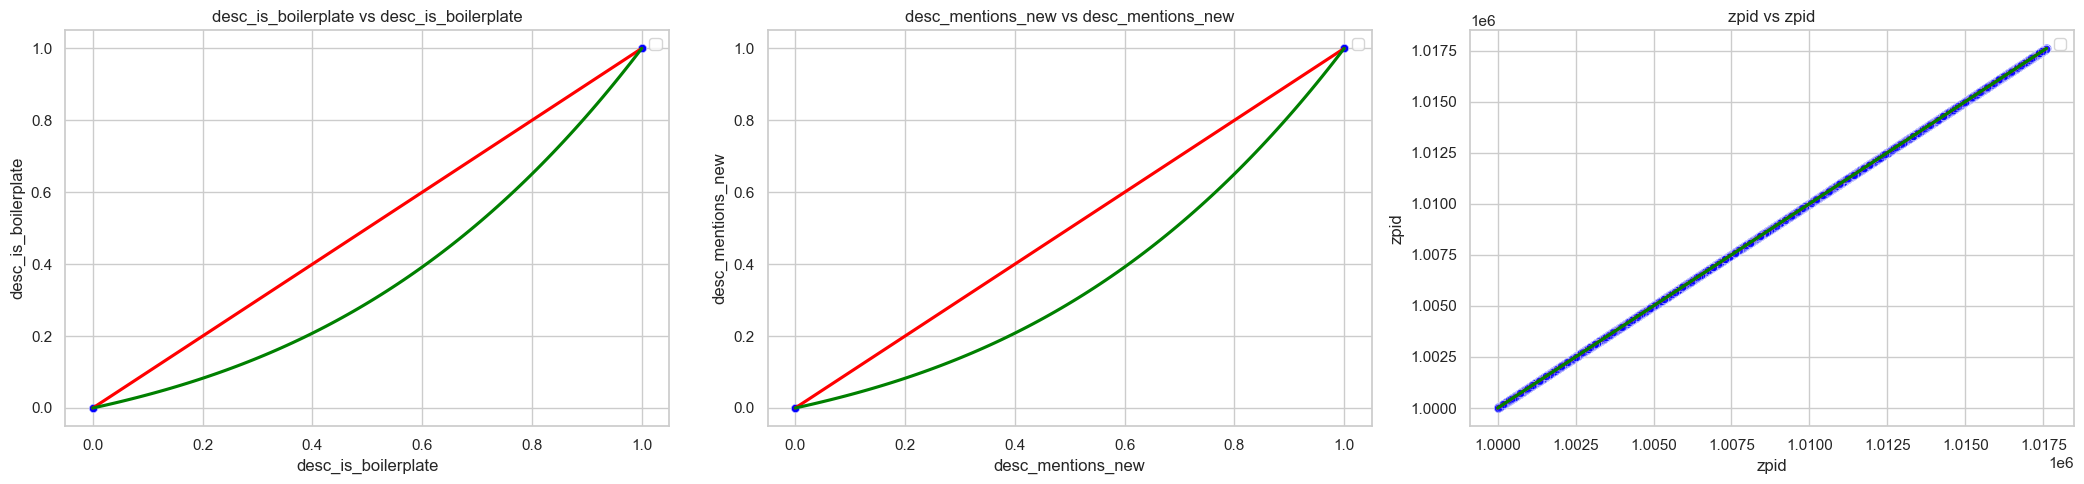

In [11]:
def plot_top_correlations(corr_matrix, data, top_n=3):
    """Grafica las top_n parejas con mayor correlación absoluta."""
    # Extraer el triángulo superior para evitar duplicados y autocrrelaciones
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    corr_flat = corr_matrix.where(mask).stack().reset_index()
    corr_flat.columns = ['Var1', 'Var2', 'Correlation']
    corr_flat['Abs_Corr'] = corr_flat['Correlation'].abs()
    top_pairs = corr_flat.sort_values(by='Abs_Corr', ascending=False).head(top_n)
    
    fig, axes = plt.subplots(1, top_n, figsize=(7 * top_n, 5))
    if top_n == 1: axes = [axes]
    
    for i, row in enumerate(top_pairs.itertuples()):
        ax = axes[i]
        x, y = row.Var1, row.Var2
        
        # Scatter plot base
        sns.scatterplot(x=data[x], y=data[y], alpha=0.5, ax=ax, color='blue')
        
        # Línea de regresión lineal (Pearson)
        sns.regplot(x=data[x], y=data[y], scatter=False, color='red', 
                    line_kws={'label': f'Lineal (r={row.Correlation:.2f})'}, ax=ax)
        
        # Línea LOWESS (No paramétrica / No lineal)
        # Nota: statsmodels tiene lowess, pero seaborn no lo incluye directo en regplot.
        # Usaremos un polinomio de grado 3 en seaborn para aproximar curvaturas no lineales.
        sns.regplot(x=data[x], y=data[y], scatter=False, order=3, color='green',
                    line_kws={'label': 'Tendencia No Lineal (Polinómica)'}, ax=ax)
        
        ax.set_title(f'{x} vs {y}', fontsize=12)
        ax.legend()
        
    plt.tight_layout()
    plt.show()

# Graficar las 3 relaciones más fuertes según Spearman
plot_top_correlations(spearman_corr, df_numeric, top_n=3)

## 3. Algoritmos Avanzados para el Análisis
La correlación tradicional solo captura relaciones de dos en dos. Para un análisis más profundo utilizaremos:

1.  **Información Mutua (Mutual Information):** De la Teoría de la Información. Mide la reducción en la incertidumbre de una variable dado el conocimiento de la otra. **Captura CUALQUIER relación (lineal, no lineal, sinusoidal, etc.)**, no solo las monótonas.
2.  **PCA (Análisis de Componentes Principales):** Algoritmo de reducción de dimensionalidad que nos dirá qué variables aportan la mayor "varianza" o información al dataset completo.

Variable objetivo seleccionada para Información Mutua: lastSoldPrice_hpi_adjusted


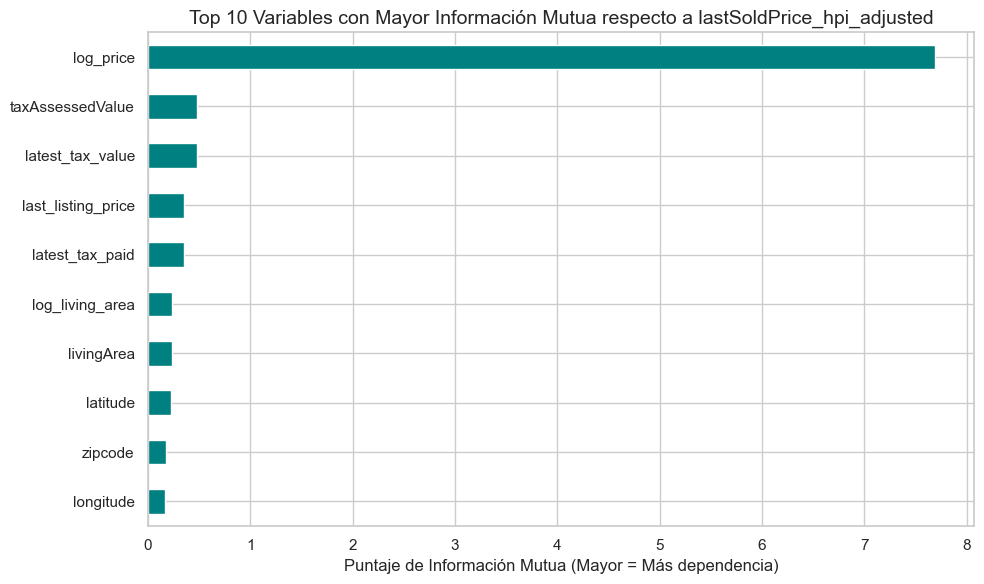

In [12]:
# Elegimos una variable objetivo (Target) para el análisis. 
# En bienes raíces, usualmente es el PRECIO o el VALOR. 
# Buscaremos la columna que parezca ser el precio/valor.
target_col = [col for col in df_numeric.columns if 'PRICE' in col.upper() or 'VAL' in col.upper()]
if not target_col:
    target_col = [df_numeric.columns[-1]] # Fallback a la última columna
    
target_col = target_col[0]
print(f"Variable objetivo seleccionada para Información Mutua: {target_col}")

# Preparar datos para sklearn (debe ser 2D)
X = df_numeric.drop(columns=[target_col])
y = df_numeric[target_col]

# Calcular Información Mutua
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(10, 6))
mi_scores.head(10).plot(kind='barh', color='teal')
plt.title(f'Top 10 Variables con Mayor Información Mutua respecto a {target_col}', fontsize=14)
plt.xlabel('Puntaje de Información Mutua (Mayor = Más dependencia)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

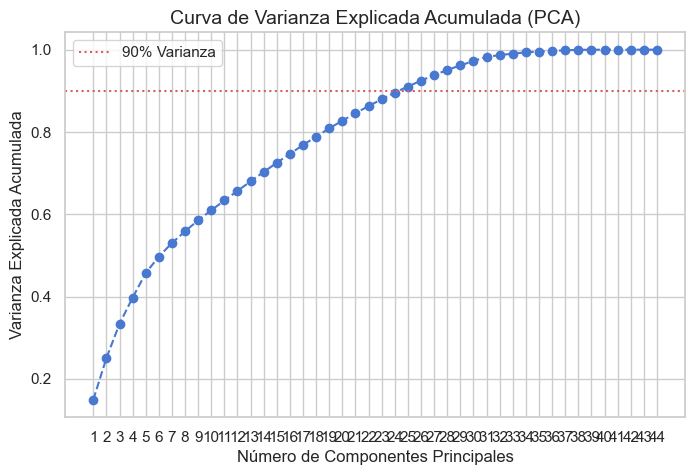


Pesos (Loadings) de las variables originales en los primeros 3 Componentes Principales:


,PC1,PC2,PC3
zpid,-0.00,-0.01,-0.00
lastSoldPrice_hpi_adjusted,0.30,-0.13,0.11
log_price,0.30,-0.14,0.10
bedrooms,0.17,-0.19,0.13
bathrooms,0.22,-0.10,0.04
livingArea,0.23,-0.18,0.13
yearBuilt,0.08,-0.04,-0.26
latitude,-0.06,0.25,0.37
longitude,-0.04,0.20,0.27
lotAreaValue,-0.05,-0.04,0.04


In [ ]:
# Estandarizar los datos (Requisito para PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Aplicar PCA
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

# Explicación de la varianza
explained_variance = pca.explained_variance_ratio_

# Gráfico de "Codo" (Scree Plot) para ver cuántos componentes retienen la información
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Curva de Varianza Explicada Acumulada (PCA)', fontsize=14)
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Varianza')
plt.legend()
plt.xticks(range(1, len(df_numeric.columns) + 1))
plt.grid(True)
plt.show()

# Carga de los componentes (Loadings): ¿Qué variables originales pesan más en el PC1?
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(df_numeric.columns))], index=df_numeric.columns)
print("\nPesos (Loadings) de las variables originales en los primeros 3 Componentes Principales:")
display(loadings.iloc[:, :3].round(2))

## 📊 Conclusiones del Análisis
*   **Pearson vs Spearman:** Si notaste diferencias grandes entre ambos heatmaps, indica la presencia de *outliers* o relaciones no lineales fuertes (típico en precios de propiedades de lujo).
*   **Scatter Plots:** La línea verde (polinómica) vs la roja (lineal) nos ayuda a visualizar visualmente si un modelo de regresión lineal sería suficiente o si necesitamos algoritmos no lineales (como Random Forest o SVM con kernels RBF).
*   **Información Mutua:** A diferencia de la correlación, esta métrica nos reveló dependencias complejas que Pearson habría ignorado.
*   **PCA:** El Scree Plot nos indica la complejidad intrínseca de los datos. Si con 3 o 4 componentes alcanzamos el 90% de varianza, significa que muchas de las columnas originales son redundantes (multicolinealidad).